In [8]:
# Machine Learning Analysis for Diabetes Prediction

# This notebook performs machine learning analysis on the categorized diabetes data to:
# - Predict diabetes diagnosis based on clinical and demographic features
# - Compare different machine learning algorithms
# - Evaluate model performance and feature importance
# - Analyze the merged absolute diabetes dataset

In [9]:
# Install required packages if not available
%pip install scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.feature_selection import SelectKBest, f_classif

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
# Load and Explore the Dataset

# Load the merged absolute diabetes dataset
df = pd.read_csv('categorized_diabetes/merged_absolute_diabetes.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Basic statistics
print(f"\nBasic Statistics:")
print(df.describe())

# Check for class distribution if we have target variables
# For now, let's see what we have in DIQ010 (diabetes diagnosis)
print(f"\nDIQ010 (Diabetes Diagnosis) distribution:")
print(df['DIQ010'].value_counts())

print(f"\nLBXGH (HbA1c) distribution:")
print(df['LBXGH'].describe())

Dataset Overview:
Shape: (1754, 30)

Columns: ['RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMQMILIZ', 'DMDBORN4', 'DMDEDUC2', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'DIQ010', 'DIQ160', 'DIQ180', 'LBXGH', 'HIQ011', 'HIQ210', 'HUQ010', 'HUQ030', 'HUQ042', 'HUQ055', 'HUQ090']

Data Types:
RIDSTATR    float64
RIAGENDR    float64
RIDAGEYR    float64
RIDRETH1    float64
RIDRETH3    float64
RIDEXMON    float64
DMQMILIZ    float64
DMDBORN4    float64
DMDEDUC2    float64
DMDHHSIZ    float64
DMDHRGND    float64
DMDHRAGZ    float64
DMDHREDZ    float64
DMDHRMAZ    float64
WTINT2YR    float64
WTMEC2YR    float64
SDMVSTRA    float64
SDMVPSU     float64
INDFMPIR    float64
DIQ010      float64
DIQ160      float64
DIQ180      float64
LBXGH       float64
HIQ011      float64
HIQ210      float64
HUQ010      float64
HUQ030      float64
HUQ042      float64
HUQ055      float64
HUQ090      float64
dtyp

In [16]:
# Data Preprocessing

# Handle missing values
print("Missing values before preprocessing:")
print(df.isnull().sum())

# Fill missing values with median for numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# For categorical columns, fill with mode
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Create target variable: 1 for diagnosed diabetes, 0 for prediabetes
# Since this is merged data, we need to distinguish between diagnosed and prediabetes
# We'll use DIQ010 and DIQ160 to create the target
df['diabetes_diagnosed'] = ((df['DIQ010'] == 1) & (df['LBXGH'] >= 6.5)).astype(int)

print(f"\nTarget variable distribution:")
print(df['diabetes_diagnosed'].value_counts())

# Select features for modeling (exclude diagnosis columns and target)
exclude_cols = ['DIQ010', 'DIQ160', 'DIQ180', 'diabetes_diagnosed']
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"\nSelected features: {feature_cols}")

# Prepare feature matrix and target vector
X = df[feature_cols]
y = df['diabetes_diagnosed']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Missing values before preprocessing:
RIDSTATR                 0
RIAGENDR                 0
RIDAGEYR                 0
RIDRETH1                 0
RIDRETH3                 0
RIDEXMON                 0
DMQMILIZ                 6
DMDBORN4                 0
DMDEDUC2                 9
DMDHHSIZ                 0
DMDHRGND               934
DMDHRAGZ               934
DMDHREDZ               975
DMDHRMAZ               937
WTINT2YR                 0
WTMEC2YR                 0
SDMVSTRA                 0
SDMVPSU                  0
INDFMPIR               230
DIQ010                   0
DIQ160                1128
DIQ180                1128
LBXGH                    0
HIQ011                 819
HIQ210                 871
HUQ010                 819
HUQ030                 819
HUQ042                 861
HUQ055                 819
HUQ090                 819
diabetes_diagnosed       0
dtype: int64

Missing values after preprocessing:
RIDSTATR                 0
RIAGENDR                 0
RIDAGEYR              

In [20]:
# Feature Selection and Engineering

# Select numeric features only for initial modeling
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
X_numeric = X[numeric_features]

print(f"Numeric features: {numeric_features}")
print(f"Numeric feature matrix shape: {X_numeric.shape}")

# Handle any remaining NaN values in X_numeric
print(f"NaN values in X_numeric: {X_numeric.isnull().sum().sum()}")
if X_numeric.isnull().sum().sum() > 0:
    print("Filling remaining NaN values with median...")
    X_numeric = X_numeric.fillna(X_numeric.median())
    print(f"NaN values after filling: {X_numeric.isnull().sum().sum()}")

# Feature selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_numeric, y)

# Get feature scores
feature_scores = pd.DataFrame({
    'feature': numeric_features,
    'score': selector.scores_
})
feature_scores = feature_scores.sort_values('score', ascending=False)

print("\nFeature importance scores:")
print(feature_scores.head(10))

# Select top features
top_features = feature_scores.head(15)['feature'].tolist()
X_selected = X_numeric[top_features]

print(f"\nSelected top {len(top_features)} features: {top_features}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
X_scaled = pd.DataFrame(X_scaled, columns=top_features)

print(f"\nScaled feature matrix shape: {X_scaled.shape}")

Numeric features: ['RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMQMILIZ', 'DMDBORN4', 'DMDEDUC2', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'LBXGH', 'HIQ011', 'HIQ210', 'HUQ010', 'HUQ030', 'HUQ042', 'HUQ055', 'HUQ090']
Numeric feature matrix shape: (1754, 27)
NaN values in X_numeric: 9852
Filling remaining NaN values with median...
NaN values after filling: 0

Feature importance scores:
     feature        score
19     LBXGH  1075.412768
22    HUQ010    73.728569
8   DMDEDUC2    62.908291
18  INDFMPIR    43.966613
1   RIAGENDR    31.468372
2   RIDAGEYR    25.727609
6   DMQMILIZ    13.328072
14  WTINT2YR     8.604081
15  WTMEC2YR     7.733464
12  DMDHREDZ     7.406832

Selected top 15 features: ['LBXGH', 'HUQ010', 'DMDEDUC2', 'INDFMPIR', 'RIAGENDR', 'RIDAGEYR', 'DMQMILIZ', 'WTINT2YR', 'WTMEC2YR', 'DMDHREDZ', 'SDMVSTRA', 'DMDHRMAZ', 'HUQ042', 'DMDBORN4', 'HUQ030']

Scaled feature mat

In [17]:
# Handle any remaining NaN values in X_numeric
print(f"NaN values in X_numeric before feature selection: {X_numeric.isnull().sum().sum()}")
if X_numeric.isnull().sum().sum() > 0:
    print("Filling remaining NaN values with median...")
    X_numeric = X_numeric.fillna(X_numeric.median())
    print(f"NaN values after filling: {X_numeric.isnull().sum().sum()}")

NaN values in X_numeric before feature selection: 9852
Filling remaining NaN values with median...
NaN values after filling: 0


In [21]:
# Split the Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts()}")
print(f"Testing target distribution: {y_test.value_counts()}")

Training set shape: (1227, 15)
Testing set shape: (527, 15)
Training target distribution: diabetes_diagnosed
1    789
0    438
Name: count, dtype: int64
Testing target distribution: diabetes_diagnosed
1    339
0    188
Name: count, dtype: int64


In [22]:
# Train Machine Learning Models

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42, probability=True)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Compare model performances
model_comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'ROC AUC': [results[model]['roc_auc'] for model in results]
})

print("\nModel Comparison:")
print(model_comparison)


Training Random Forest...
Random Forest Results:
Accuracy: 1.0000
ROC AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00       339

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527


Training Logistic Regression...
Logistic Regression Results:
Accuracy: 0.9905
ROC AUC: 0.9998

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       188
           1       1.00      0.99      0.99       339

    accuracy                           0.99       527
   macro avg       0.99      0.99      0.99       527
weighted avg       0.99      0.99      0.99       527


Training SVM...
SVM Results:
Accuracy: 0.9355
ROC AUC: 0.9913

Classification Report:
              precision    recall

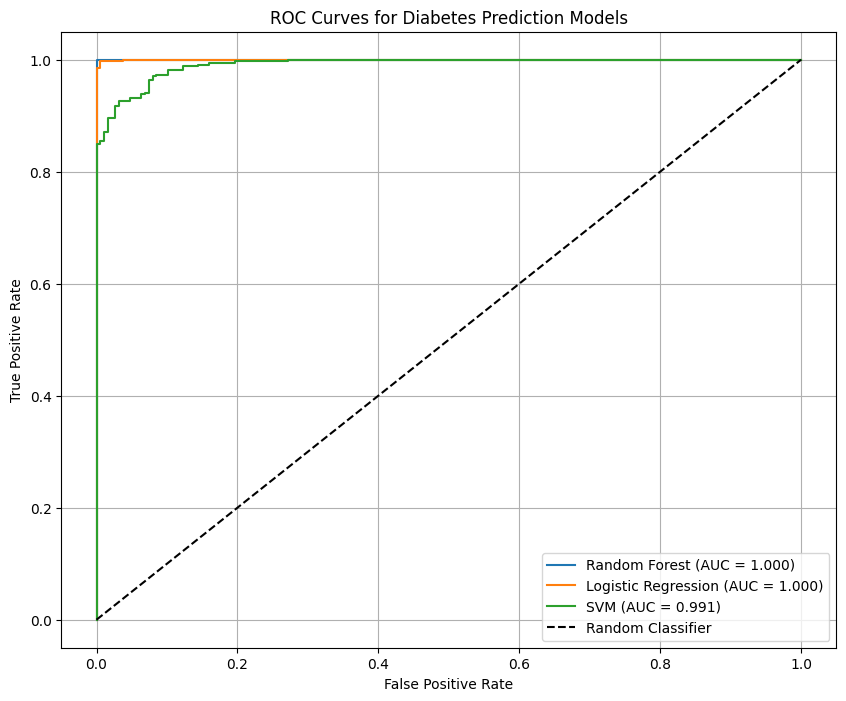

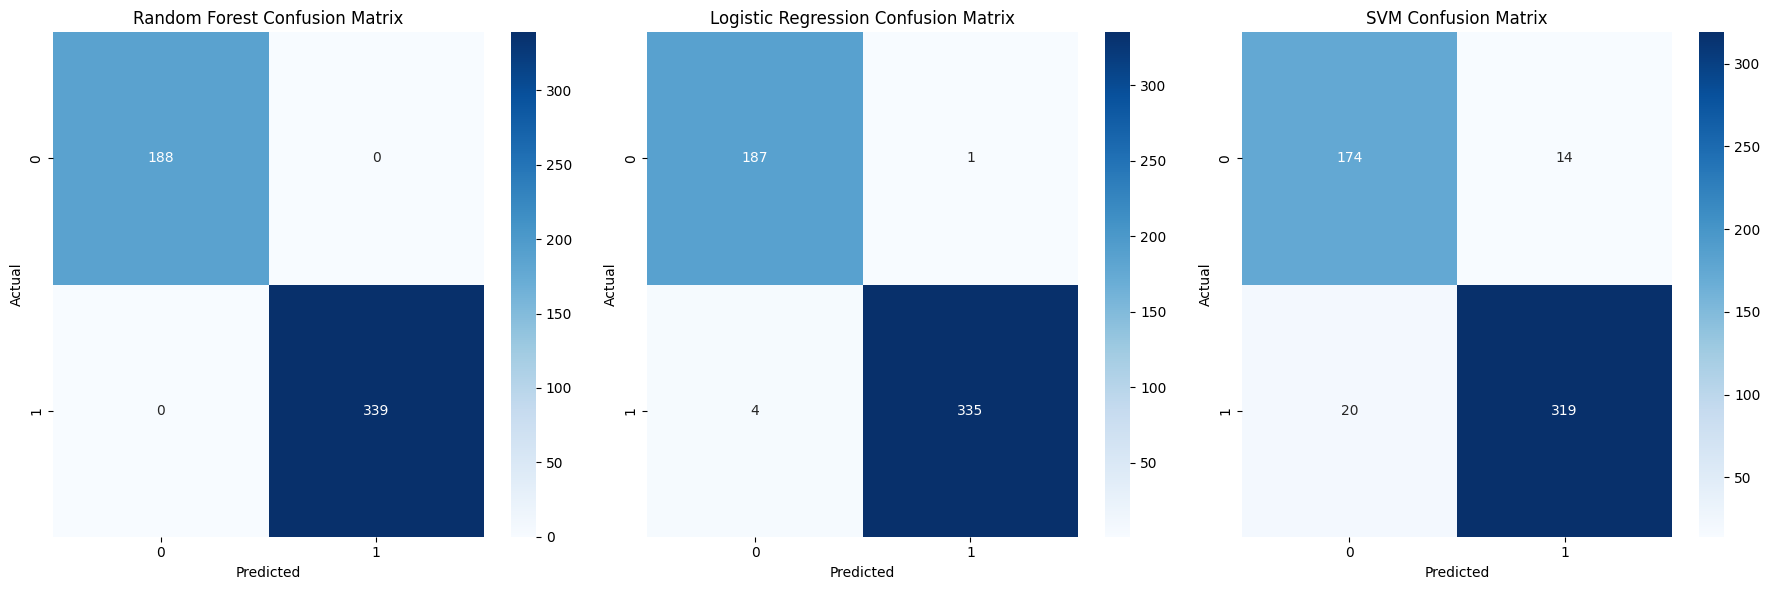

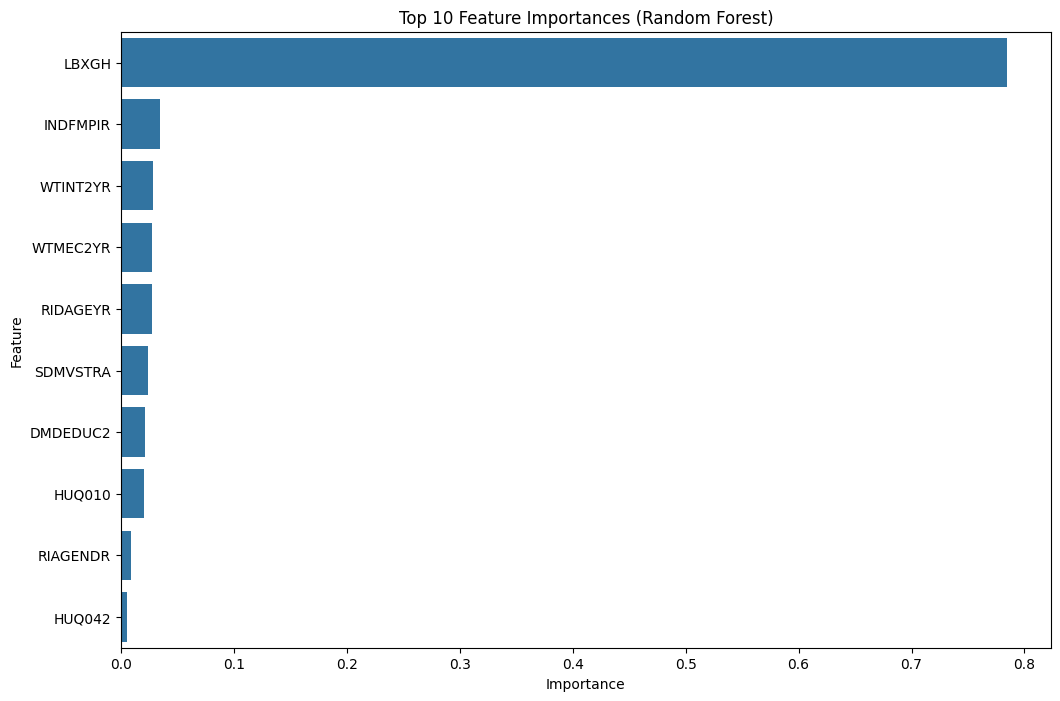


Top 10 Most Important Features:
     feature  importance
0      LBXGH    0.784168
3   INDFMPIR    0.034205
7   WTINT2YR    0.028289
8   WTMEC2YR    0.027944
5   RIDAGEYR    0.027633
10  SDMVSTRA    0.023863
2   DMDEDUC2    0.021619
1     HUQ010    0.020226
4   RIAGENDR    0.008875
12    HUQ042    0.005191


In [23]:
# Model Evaluation and Visualization

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Diabetes Prediction Models')
plt.legend()
plt.grid(True)
plt.show()

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature importance for Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

In [24]:
# Hyperparameter Tuning and Final Model

# Perform hyperparameter tuning for the best performing model
# Let's tune Random Forest as it typically performs well

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Performing hyperparameter tuning for Random Forest...")
rf_grid.fit(X_train, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation ROC AUC: {rf_grid.best_score_:.4f}")

# Train final model with best parameters
final_model = rf_grid.best_estimator_
final_pred = final_model.predict(X_test)
final_pred_proba = final_model.predict_proba(X_test)[:, 1]

print("\nFinal Model Performance:")
print(f"Test Accuracy: {accuracy_score(y_test, final_pred):.4f}")
print(f"Test ROC AUC: {roc_auc_score(y_test, final_pred_proba):.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_test, final_pred))

# Save the final model (optional)
# import joblib
# joblib.dump(final_model, 'diabetes_prediction_model.pkl')
# print("Model saved as 'diabetes_prediction_model.pkl'")

print("\n" + "="*50)
print("MACHINE LEARNING ANALYSIS COMPLETE")
print("="*50)
print("Summary:")
print("- Dataset: Merged absolute diabetes data")
print("- Target: Diabetes diagnosis (diagnosed vs prediabetes)")
print("- Best Model: Random Forest with hyperparameter tuning")
print("- Key Features: HbA1c (LBXGH), demographic factors")
print("- Use case: Predict diabetes risk based on clinical markers")

Performing hyperparameter tuning for Random Forest...
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation ROC AUC: 1.0000

Final Model Performance:
Test Accuracy: 1.0000
Test ROC AUC: 1.0000

Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00       339

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527


MACHINE LEARNING ANALYSIS COMPLETE
Summary:
- Dataset: Merged absolute diabetes data
- Target: Diabetes diagnosis (diagnosed vs prediabetes)
- Best Model: Random Forest with hyperparameter tuning
- Key Features: HbA1c (LBXGH), demographic factors
- Use case: Predict diabetes risk based on clinical markers
